This notebook shows an example of a case/control analysis done using a subset of the 1000 Genomes dataset, with samples pertaining to the EUR ancestry. The phenotypes have been simulated randomly.

In [1]:
import csv
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# random seed for reproducibility
np.random.seed(42)

In [12]:
	
snp_info = []
data = []
with open("gwas_data.csv") as csvfile:
    reader = csv.reader(csvfile, delimiter=',')

    for row in reader:

        snp_info.append(row[0:3])
        data.append(row[3:])

In [13]:
snp_header = snp_info[0]
snp_info = snp_info[1:]

samples = data[0]
data = data[1:]

In [14]:
snp_info = np.array(snp_info)
data = np.array(data).astype(int)

snp_header = np.array(snp_header)
samples = np.array(samples)

In [15]:
print(snp_info.shape)
print(data.shape)
print()
print(snp_header.shape)
print(samples.shape)

(27357, 3)
(27357, 502)

(3,)
(502,)


In [16]:
print("snp_header:")
print(snp_header)
print()

print("samples:")
print(samples[0:3])
print()

print("snp_info:")
print(snp_info[0:5])
print()

print("data:")
print(data[0:5,0:3])
print()

snp_header:
['snp_id' 'chr' 'pos']

samples:
['0' '1' '2']

snp_info:
[['rs528671093' '15' '20003714']
 ['esv3635717' '15' '20005872']
 ['rs61996167' '15' '20007752']
 ['rs529669657' '15' '20013544']
 ['rs558165623' '15' '20015809']]

data:
[[0 0 0]
 [0 0 0]
 [0 0 1]
 [0 0 0]
 [0 0 0]]



In [52]:
# simulating phenotypes

import numpy as np
import pandas as pd
from scipy.special import expit  # sigmoid

num_snps, N = data.shape
rng = np.random.default_rng(0)

m_causal = 200  # number of causal SNPs
causal_idx = rng.choice(num_snps, size=m_causal, replace=False)

# effect sizes for causal SNPs
betas = rng.normal(loc=0.0, scale=0.8, size=m_causal).astype(np.float32)

# polygenic score per individual: PRS shape (N,)
PRS = (data[causal_idx].T @ betas)

# optional: standardize PRS for easier control of prevalence
PRS = (PRS - PRS.mean()) / PRS.std()

# choose prevalence by setting intercept alpha
prevalence = 0.3  # fraction of cases you want on average
alpha = np.log(prevalence / (1 - prevalence))  # baseline log-odds

# compute probabilities and sample case/control labels
p = expit(alpha + PRS)          # shape (N,)
y = rng.binomial(1, p, size=N)  # 0/1

# # Save phenotype in the same sample order as columns
# phenodf = pd.DataFrame({"IID": df.columns[3:], "case": y, "prob": p})
# phenodf.to_csv("phenotypes_casecontrol.csv", index=False)

print("Cases:", y.sum(), "Controls:", (y == 0).sum())
print("Saved: phenotypes_casecontrol.csv")

Cases: 171 Controls: 331
Saved: phenotypes_casecontrol.csv


In [53]:
first_snp = data[0,:]

print(first_snp)

[0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 1 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 

In [54]:
total_alleles_per_snp = len(samples)*2

print(total_alleles_per_snp)

1004


In [60]:
ref_allele_count = 2 * np.sum(first_snp == 0) + np.sum(first_snp == 1)
# purposely writing this in a mathematically inefficient way to communicate the point
# could just be total_alleles_per_snp - np.sum(first_snp)

print(ref_allele_count)

988


In [61]:
alt_allele_count = 2 * np.sum(first_snp == 2) + np.sum(first_snp == 1)
# purposely writing this in a mathematically inefficient way to communicate the point
# could just be np.sum(first_snp)

print(alt_allele_count)

16


In [62]:
maf = min(ref_allele_count, alt_allele_count) / total_alleles_per_snp

print(maf)

0.01593625498007968


# GWAS Analysis

In [63]:
first_snp = data[0, :]

X = sm.add_constant(first_snp)
result = sm.Logit(y, X).fit(disp=False)

print(result.summary())

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  502
Model:                          Logit   Df Residuals:                      500
Method:                           MLE   Df Model:                            1
Date:                Wed, 04 Mar 2026   Pseudo R-squ.:                0.001034
Time:                        16:13:08   Log-Likelihood:                -321.68
converged:                       True   LL-Null:                       -322.01
Covariance Type:            nonrobust   LLR p-value:                    0.4145
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.6747      0.096     -7.033      0.000      -0.863      -0.487
x1             0.4234      0.513      0.825      0.409      -0.582       1.429


In [64]:
p_value = result.pvalues[1] # p‑value for the SNP term

print(p_value)

0.40921251661516633


In [65]:
p_values = []

for i in range(data.shape[0]):

    snp_genotypes = data[i, :].astype(float)

    # skip SNPs with no variation
    if np.std(snp_genotypes) == 0:
        p_values.append(1.0)
        continue

    X = sm.add_constant(snp_genotypes)

    try:
        result = sm.Logit(y, X).fit(disp=False)

        if result.mle_retvals["converged"]:
            p_values.append(result.pvalues[1])
        else:
            p_values.append(1.0)

    except:
        p_values.append(1.0)

/Users/spoorthikalkunte/miniforge3/envs/ctn_arm/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/spoorthikalkunte/miniforge3/envs/ctn_arm/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/spoorthikalkunte/miniforge3/envs/ctn_arm/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/spoorthikalkunte/miniforge3/envs/ctn_arm/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum 

In [66]:
p_values = np.array(p_values)

In [67]:
print(np.sum(np.isnan(p_values))) # should be 0
print(p_values[0:5])

0
[0.40921252 0.56855776 0.85921757 0.7997145  0.94690848]


In [68]:
p_values_bonf = p_values * len(p_values)

In [69]:
print(snp_info[p_values_bonf <= 0.05, ])

[]


In [70]:
filtered_snp_chromosomes = []
filtered_snp_positions = []


for i in range(snp_info.shape[0]):
    
    # snp_position = snp_info[i,2]
    
    # chromosome, position = snp_position.split(":")
    
    # chromosome = chromosome.replace('chr', '')
    
    chromosome = int(snp_info[i,1])
    position = int(snp_info[i,2])
    
    
    filtered_snp_chromosomes.append(chromosome)
    filtered_snp_positions.append(position)
    
    
filtered_snp_chromosomes = np.array(filtered_snp_chromosomes)
filtered_snp_positions = np.array(filtered_snp_positions)

In [71]:
neg_log_p_values = -np.log10(p_values)

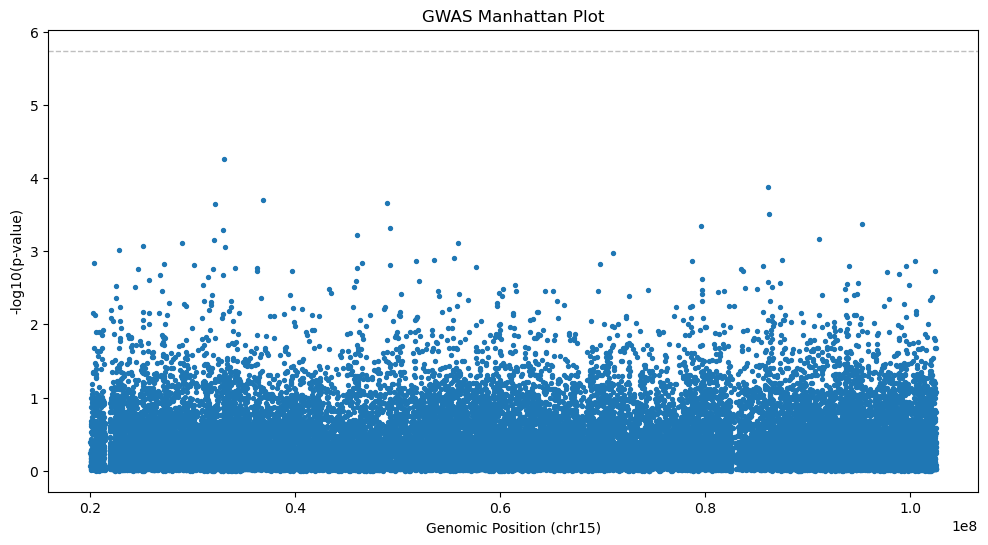

In [72]:
neg_log_p_values = -np.log10(p_values)

plt.figure(figsize=(12,6))

plt.scatter(filtered_snp_positions, neg_log_p_values, s=8)

sig_thresh = -np.log10(0.05/len(p_values))

plt.axhline(sig_thresh,
            color='grey',
            linestyle='--',
            linewidth=1,
            alpha=0.5)

plt.xlabel("Genomic Position (chr15)")
plt.ylabel("-log10(p-value)")
plt.title("GWAS Manhattan Plot")

plt.savefig("manhattan_plot.pdf")
plt.show()

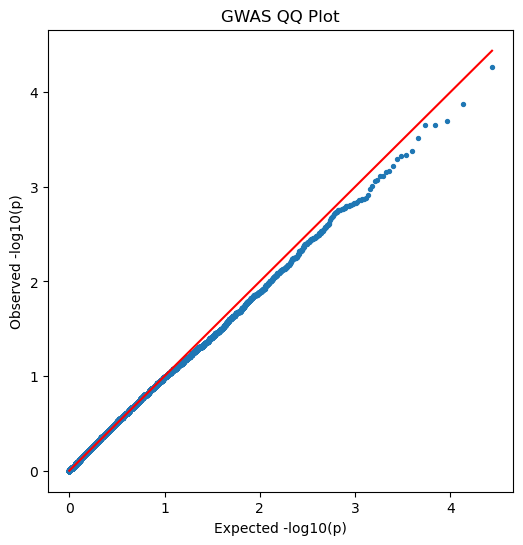

In [73]:
observed = -np.log10(np.sort(p_values))

m = len(p_values)

expected = -np.log10(np.arange(1, m+1) / (m+1))

plt.figure(figsize=(6,6))

plt.scatter(expected, observed, s=8)

# diagonal reference
max_val = max(expected.max(), observed.max())
plt.plot([0, max_val], [0, max_val], color='red')

plt.xlabel("Expected -log10(p)")
plt.ylabel("Observed -log10(p)")
plt.title("GWAS QQ Plot")

plt.show()

No genome-wide significant SNPs observed